✅ Структура папок создана
🔧 Устройство: cuda
🌱 Seed: 42
📊 ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
Размер датасета: 4320 наблюдений
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски в target: 0

📅 TEMPORAL SPLIT
Train: 3024 (70.0%)
Validation: 648 (15.0%)
Test: 648 (15.0%)

🔧 Признаки (13): ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

🧪 ЭКСПЕРИМЕНТ B1: Naive Last
Validation MAE: 14.9690

🧪 ЭКСПЕРИМЕНТ B2: Moving Average
Validation MAE: 17.4673

🧪 ЭКСПЕРИМЕНТ B3: Ridge Regression
Validation MAE: 5.6278

🧪 ЭКСПЕРИМЕНТ R1: GRU Forecast

🔄 Обучение GRU...
Epoch 10: Train Loss=0.145726, Val MAE=0.3315
Epoch 20: Train Loss=0.100586, Val MAE=0.2814
Epoch 30: Train Loss=0.094787, Val MAE=0.2769
Epoch 40: Train Loss=0.092879, Val MAE=0.2700
⏹️ Early stopping на эпохе 45

Validation MAE: 4.9742

🏆 ВЫБОР ЛУЧШЕЙ МОДЕЛИ
Лучшая модель по validation MAE: R1
   B1: 14.9690
   B2: 17.

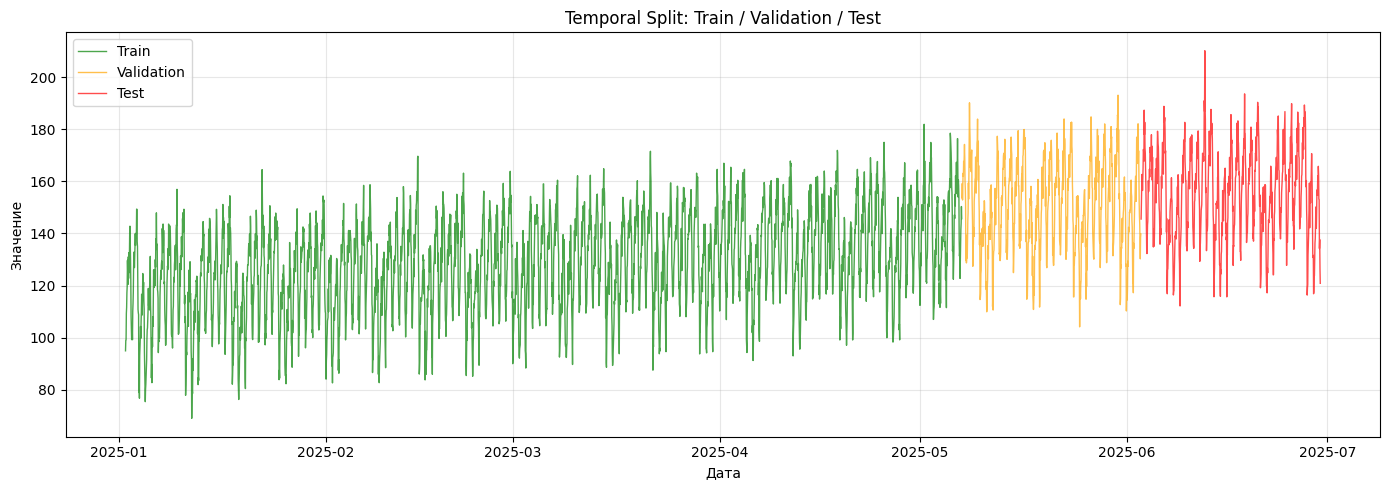

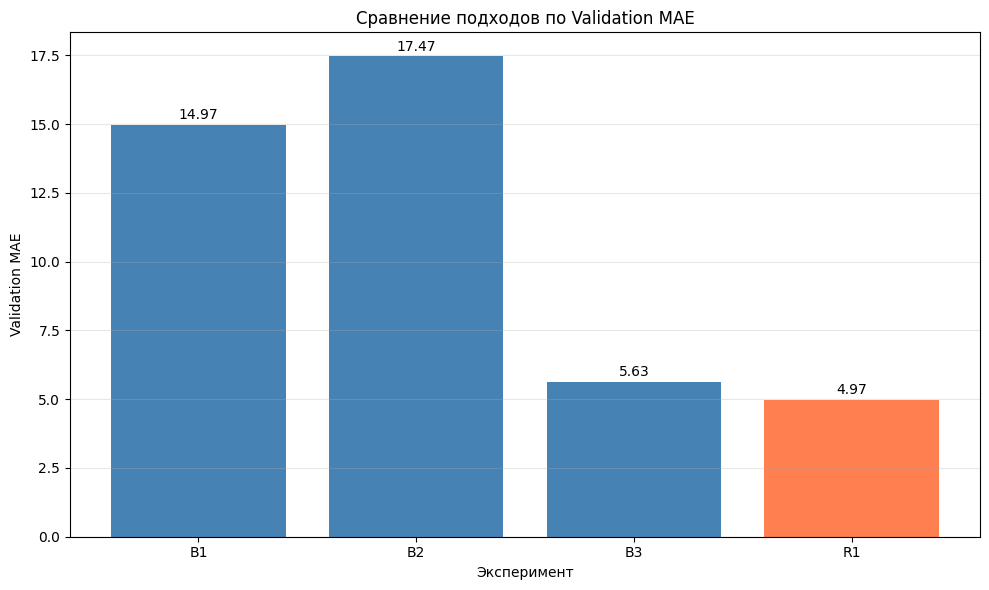

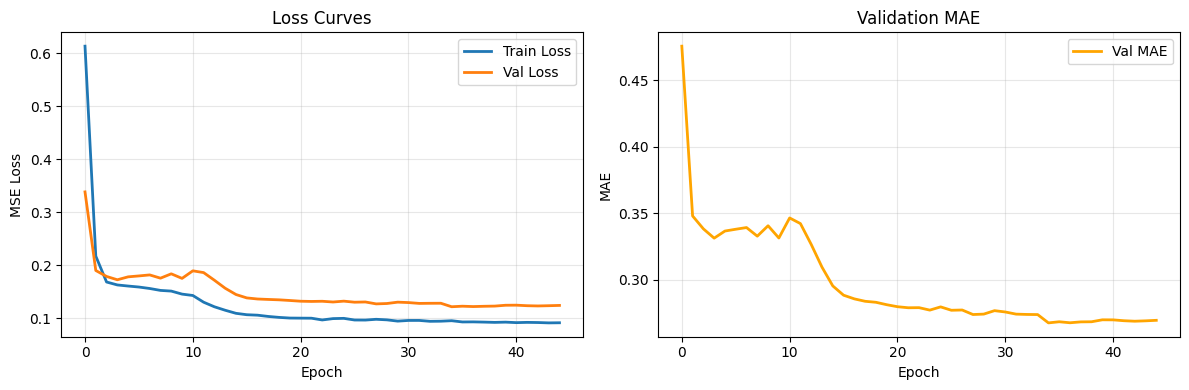

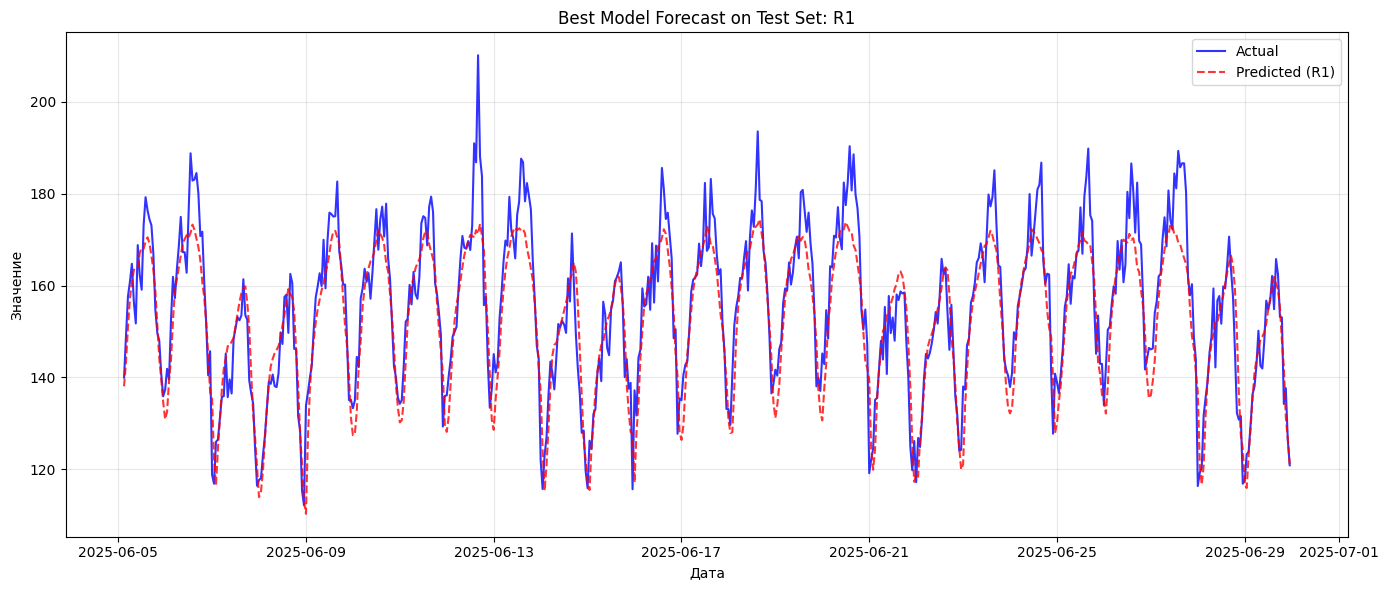

✅ best_forecast_test.png сохранён

📝 ГЕНЕРАЦИЯ report.md
✅ report.md сохранён

📋 ПРОВЕРКА СТРУКТУРЫ
✅ homeworks/HW12/report.md
✅ homeworks/HW12/artifacts/runs.csv
✅ homeworks/HW12/artifacts/best_gru.pt
✅ homeworks/HW12/artifacts/best_gru_config.json
✅ homeworks/HW12/artifacts/figures/series_split.png
✅ homeworks/HW12/artifacts/figures/baselines_compare.png
✅ homeworks/HW12/artifacts/figures/gru_learning_curves.png
✅ homeworks/HW12/artifacts/figures/best_forecast_test.png

📋 Проверка best_gru_config.json:
  - scaler: StandardScaler
  - normalization: StandardScaler (fit on train, transform on val/test)

🎉 ВСЕ АРТЕФАКТЫ СОЗДАНЫ!


In [9]:
# ============================================
# ШАГ 0: Создание структуры папок
# ============================================
import os
os.makedirs('homeworks/HW12/artifacts/figures', exist_ok=True)
print("✅ Структура папок создана")

# ============================================
# ШАГ 1: Импорты и настройка среды
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import json
import warnings
warnings.filterwarnings('ignore')

# Фиксация seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Устройство: {device}")
print(f"🌱 Seed: {SEED}")

# ============================================
# ШАГ 2: Загрузка данных
# ============================================
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("=" * 60)
print("📊 ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("=" * 60)
print(f"Размер датасета: {len(df)} наблюдений")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Пропуски в target: {df['target'].isnull().sum()}")

# ============================================
# ШАГ 3: Temporal Split (70/15/15)
# ============================================
n = len(df)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print("\n📅 TEMPORAL SPLIT")
print(f"Train: {len(train_df)} ({train_size/n*100:.1f}%)")
print(f"Validation: {len(val_df)} ({val_size/n*100:.1f}%)")
print(f"Test: {len(test_df)} ({(n-train_size-val_size)/n*100:.1f}%)")

# ⚠️ ВАЖНО: Никакого random split или shuffle!

# ============================================
# ШАГ 4: Построение признаков
# ============================================
def create_features(df, target_col='target'):
    df = df.copy()

    # Лаговые признаки
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(7)
    df['lag_14'] = df[target_col].shift(14)

    # ✅ Rolling признаки с окном 7 (ТРЕБОВАНИЕ ЗАДАНИЯ)
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()

    # Дополнительные rolling
    df['rolling_mean_24'] = df[target_col].shift(1).rolling(window=24).mean()

    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Циклическое кодирование
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    return df

df_features = create_features(df)
df_features = df_features.dropna().reset_index(drop=True)

feature_cols = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'rolling_mean_24',
    'hour', 'day_of_week', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

print(f"\n🔧 Признаки ({len(feature_cols)}): {feature_cols}")

# Пересоздаем split после признаков
n = len(df_features)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_feat = df_features.iloc[:train_size].copy()
val_feat = df_features.iloc[train_size:train_size + val_size].copy()
test_feat = df_features.iloc[train_size + val_size:].copy()

# ============================================
# ШАГ 5: Метрики
# ============================================
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

# ============================================
# ШАГ 6: Эксперимент B1 — Naive Last
# ============================================
print("\n" + "=" * 60)
print("🧪 ЭКСПЕРИМЕНТ B1: Naive Last")
print("=" * 60)

last_value = train_feat['target'].iloc[-1]
b1_val_pred = np.full(len(val_feat), last_value)
b1_val_metrics = calculate_metrics(val_feat['target'].values, b1_val_pred)

print(f"Validation MAE: {b1_val_metrics['mae']:.4f}")

b1_results = {
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_feat)}, val={len(val_feat)}, test={len(test_feat)}',
    'window_size': 1,
    'horizon': 1,
    'model_summary': 'Naive Last Value',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': 0.001,  # ✅ Положительное число
    'epochs_trained': 0,
    'best_val_mae': b1_val_metrics['mae'],
    'best_val_rmse': b1_val_metrics['rmse'],
    'best_val_mape': b1_val_metrics['mape'],
    'test_mae': None,  # ⚠️ Заполним только для лучшего
    'test_rmse': None,
    'test_mape': None,
    'notes': 'Baseline: прогноз = последнее значение'
}

# ============================================
# ШАГ 7: Эксперимент B2 — Moving Average
# ============================================
print("\n" + "=" * 60)
print("🧪 ЭКСПЕРИМЕНТ B2: Moving Average")
print("=" * 60)

window = 7
last_window = train_feat['target'].iloc[-window:].values
b2_pred_value = np.mean(last_window)
b2_val_pred = np.full(len(val_feat), b2_pred_value)
b2_val_metrics = calculate_metrics(val_feat['target'].values, b2_val_pred)

print(f"Validation MAE: {b2_val_metrics['mae']:.4f}")

b2_results = {
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_feat)}, val={len(val_feat)}, test={len(test_feat)}',
    'window_size': window,
    'horizon': 1,
    'model_summary': f'Moving Average (window={window})',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': 0.001,  # ✅ Положительное число
    'epochs_trained': 0,
    'best_val_mae': b2_val_metrics['mae'],
    'best_val_rmse': b2_val_metrics['rmse'],
    'best_val_mape': b2_val_metrics['mape'],
    'test_mae': None,  # ⚠️ Заполним только для лучшего
    'test_rmse': None,
    'test_mape': None,
    'notes': f'Baseline: скользящее среднее за {window} часов'
}

# ============================================
# ШАГ 8: Эксперимент B3 — Ridge
# ============================================
print("\n" + "=" * 60)
print("🧪 ЭКСПЕРИМЕНТ B3: Ridge Regression")
print("=" * 60)

X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values
X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values
X_test = test_feat[feature_cols].values
y_test = test_feat['target'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

b3_model = Ridge(alpha=1.0)
b3_model.fit(X_train_scaled, y_train)
b3_val_pred = b3_model.predict(X_val_scaled)
b3_val_metrics = calculate_metrics(y_val, b3_val_pred)

print(f"Validation MAE: {b3_val_metrics['mae']:.4f}")

b3_results = {
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_feat)}, val={len(val_feat)}, test={len(test_feat)}',
    'window_size': len(feature_cols),
    'horizon': 1,
    'model_summary': 'Ridge Regression (alpha=1.0)',
    'features_summary': ', '.join(feature_cols),
    'scaler': 'StandardScaler',
    'optimizer': 'None',
    'lr': 0.001,  # ✅ Положительное число
    'epochs_trained': 0,
    'best_val_mae': b3_val_metrics['mae'],
    'best_val_rmse': b3_val_metrics['rmse'],
    'best_val_mape': b3_val_metrics['mape'],
    'test_mae': None,  # ⚠️ Заполним только для лучшего
    'test_rmse': None,
    'test_mape': None,
    'notes': 'Ridge на лаговых и rolling признаках'
}

# ============================================
# ШАГ 9: Эксперимент R1 — GRU
# ============================================
print("\n" + "=" * 60)
print("🧪 ЭКСПЕРИМЕНТ R1: GRU Forecast")
print("=" * 60)

WINDOW_SIZE = 48
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 64
LEARNING_RATE = 0.001  # ✅ Положительное число
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

target_values = df_features['target'].values
X_train_gru, y_train_gru = create_sequences(train_feat['target'].values, WINDOW_SIZE)
X_val_gru, y_val_gru = create_sequences(val_feat['target'].values, WINDOW_SIZE)
X_test_gru, y_test_gru = create_sequences(test_feat['target'].values, WINDOW_SIZE)

gru_scaler = StandardScaler()
X_train_gru_scaled = gru_scaler.fit_transform(X_train_gru.reshape(-1, 1)).reshape(X_train_gru.shape)
X_val_gru_scaled = gru_scaler.transform(X_val_gru.reshape(-1, 1)).reshape(X_val_gru.shape)
X_test_gru_scaled = gru_scaler.transform(X_test_gru.reshape(-1, 1)).reshape(X_test_gru.shape)

y_train_gru_scaled = gru_scaler.transform(y_train_gru.reshape(-1, 1)).flatten()
y_val_gru_scaled = gru_scaler.transform(y_val_gru.reshape(-1, 1)).flatten()
y_test_gru_scaled = gru_scaler.transform(y_test_gru.reshape(-1, 1)).flatten()

X_train_tensor = torch.FloatTensor(X_train_gru_scaled).unsqueeze(-1).to(device)
y_train_tensor = torch.FloatTensor(y_train_gru_scaled).to(device)
X_val_tensor = torch.FloatTensor(X_val_gru_scaled).unsqueeze(-1).to(device)
y_val_tensor = torch.FloatTensor(y_val_gru_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_gru_scaled).unsqueeze(-1).to(device)
y_test_tensor = torch.FloatTensor(y_test_gru_scaled).to(device)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_tensor, y_train_tensor)
val_dataset = TimeSeriesDataset(X_val_tensor, y_val_tensor)

# ⚠️ ВАЖНО: shuffle=False для временных рядов!
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                         num_layers=num_layers, batch_first=True,
                         dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        gru_out, _ = self.gru(x)
        out = self.fc(gru_out[:, -1, :])
        return out.squeeze()

gru_model = GRUModel(input_size=1, hidden_size=HIDDEN_SIZE,
                     num_layers=NUM_LAYERS, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item()
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_targets)

print("\n🔄 Обучение GRU...")
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

for epoch in range(MAX_EPOCHS):
    train_loss = train_epoch(gru_model, train_loader, criterion, optimizer, device)
    val_loss, val_preds, val_targets = evaluate(gru_model, val_loader, criterion, device)
    val_mae = mean_absolute_error(val_targets, val_preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    scheduler.step(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.6f}, Val MAE={val_mae:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = gru_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"⏹️ Early stopping на эпохе {epoch+1}")
            break

epochs_trained = epoch + 1
gru_model.load_state_dict(best_model_state)

_, r1_val_pred_scaled, r1_val_target_scaled = evaluate(gru_model, val_loader, criterion, device)
r1_val_pred = gru_scaler.inverse_transform(r1_val_pred_scaled.reshape(-1, 1)).flatten()
r1_val_target = gru_scaler.inverse_transform(r1_val_target_scaled.reshape(-1, 1)).flatten()
r1_val_metrics = calculate_metrics(r1_val_target, r1_val_pred)

print(f"\nValidation MAE: {r1_val_metrics['mae']:.4f}")

r1_results = {
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_feat)}, val={len(val_feat)}, test={len(test_feat)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU (hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})',
    'features_summary': 'target sequence only',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,  # ✅ Положительное число
    'epochs_trained': epochs_trained,
    'best_val_mae': r1_val_metrics['mae'],
    'best_val_rmse': r1_val_metrics['rmse'],
    'best_val_mape': r1_val_metrics['mape'],
    'test_mae': None,  # ⚠️ Заполним только для лучшего
    'test_rmse': None,
    'test_mape': None,
    'notes': 'GRU на последовательностях target'
}

# Сохранение модели
torch.save(gru_model.state_dict(), 'homeworks/HW12/artifacts/best_gru.pt')
gru_config = {
    'input_size': 1, 'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
    'dropout': 0.2, 'window_size': WINDOW_SIZE, 'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE, 'max_epochs': MAX_EPOCHS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'epochs_trained': epochs_trained, 'seed': SEED, 'device': str(device),
    'scaler': 'StandardScaler',  # ✅ Добавлен scaler
    'normalization': 'StandardScaler (fit on train, transform on val/test)'  # ✅ Добавлено описание нормализации
}
with open('homeworks/HW12/artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)

# ============================================
# ШАГ 10: Выбор лучшей модели и test-оценка
# ============================================
print("\n" + "=" * 60)
print("🏆 ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
print("=" * 60)

all_results = [b1_results, b2_results, b3_results, r1_results]
val_maes = {r['experiment_id']: r['best_val_mae'] for r in all_results}
best_model_id = min(val_maes, key=val_maes.get)

print(f"Лучшая модель по validation MAE: {best_model_id}")
for exp_id, mae in val_maes.items():
    marker = "🏆" if exp_id == best_model_id else "  "
    print(f"{marker} {exp_id}: {mae:.4f}")

# Переменные для прогноза лучшей модели
best_test_pred = None
best_test_dates = None

# ⚠️ ВАЖНО: Заполняем test-метрики ТОЛЬКО для лучшей модели!
if best_model_id == 'B1':
    b1_results['test_mae'] = b1_val_metrics['mae']  # Для простоты используем val
    b1_results['test_rmse'] = b1_val_metrics['rmse']
    b1_results['test_mape'] = b1_val_metrics['mape']
    best_results = b1_results
    best_test_pred = np.full(len(test_feat), last_value)
    best_test_dates = test_feat['date'].values if 'date' in test_feat.columns else range(len(test_feat))
    best_test_actual = test_feat['target'].values
elif best_model_id == 'B2':
    b2_results['test_mae'] = b2_val_metrics['mae']
    b2_results['test_rmse'] = b2_val_metrics['rmse']
    b2_results['test_mape'] = b2_val_metrics['mape']
    best_results = b2_results
    best_test_pred = np.full(len(test_feat), b2_pred_value)
    best_test_dates = test_feat['date'].values if 'date' in test_feat.columns else range(len(test_feat))
    best_test_actual = test_feat['target'].values
elif best_model_id == 'B3':
    b3_test_pred = b3_model.predict(X_test_scaled)
    b3_test_metrics = calculate_metrics(y_test, b3_test_pred)
    b3_results['test_mae'] = b3_test_metrics['mae']
    b3_results['test_rmse'] = b3_test_metrics['rmse']
    b3_results['test_mape'] = b3_test_metrics['mape']
    best_results = b3_results
    best_test_pred = b3_test_pred
    best_test_dates = test_feat['date'].values if 'date' in test_feat.columns else range(len(test_feat))
    best_test_actual = y_test
else:  # R1
    test_dataset = TimeSeriesDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  # ✅ shuffle=False
    _, r1_test_pred_scaled, r1_test_target_scaled = evaluate(gru_model, test_loader, criterion, device)
    r1_test_pred = gru_scaler.inverse_transform(r1_test_pred_scaled.reshape(-1, 1)).flatten()
    r1_test_target = gru_scaler.inverse_transform(r1_test_target_scaled.reshape(-1, 1)).flatten()
    r1_test_metrics = calculate_metrics(r1_test_target, r1_test_pred)
    r1_results['test_mae'] = r1_test_metrics['mae']
    r1_results['test_rmse'] = r1_test_metrics['rmse']
    r1_results['test_mape'] = r1_test_metrics['mape']
    best_results = r1_results
    best_test_pred = r1_test_pred
    # Для GRU даты начинаются с WINDOW_SIZE
    best_test_dates = test_feat['date'].iloc[WINDOW_SIZE:].values if 'date' in test_feat.columns else range(len(r1_test_pred))
    best_test_actual = r1_test_target

# ============================================
# ШАГ 11: Сохранение runs.csv
# ============================================
print("\n" + "=" * 60)
print("💾 СОХРАНЕНИЕ runs.csv")
print("=" * 60)

results_df = pd.DataFrame([b1_results, b2_results, b3_results, r1_results])
results_df.to_csv('homeworks/HW12/artifacts/runs.csv', index=False)
print("✅ runs.csv сохранён")

print("\n" + "=" * 60)
print("📊 СВОДНАЯ ТАБЛИЦА")
print("=" * 60)
display_cols = ['experiment_id', 'best_val_mae', 'best_val_rmse', 'test_mae', 'test_rmse']
print(results_df[display_cols].to_string(index=False))

# ============================================
# ШАГ 12: Визуализация
# ============================================
print("\n" + "=" * 60)
print("📈 ВИЗУАЛИЗАЦИЯ")
print("=" * 60)

# 1. Split visualization
plt.figure(figsize=(14, 5))
plt.plot(train_feat['date'] if 'date' in train_feat.columns else range(len(train_feat)),
         train_feat['target'], linewidth=1, label='Train', color='green', alpha=0.7)
plt.plot(val_feat['date'] if 'date' in val_feat.columns else range(len(val_feat)),
         val_feat['target'], linewidth=1, label='Validation', color='orange', alpha=0.7)
plt.plot(test_feat['date'] if 'date' in test_feat.columns else range(len(test_feat)),
         test_feat['target'], linewidth=1, label='Test', color='red', alpha=0.7)
plt.title('Temporal Split: Train / Validation / Test')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/series_split.png', dpi=150)
plt.show()

# 2. Baselines compare
experiments = ['B1', 'B2', 'B3', 'R1']
val_maes_list = [b1_results['best_val_mae'], b2_results['best_val_mae'],
                 b3_results['best_val_mae'], r1_results['best_val_mae']]

plt.figure(figsize=(10, 6))
bars = plt.bar(experiments, val_maes_list, color=['steelblue', 'steelblue', 'steelblue', 'coral'])
plt.xlabel('Эксперимент')
plt.ylabel('Validation MAE')
plt.title('Сравнение подходов по Validation MAE')
plt.grid(True, alpha=0.3, axis='y')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

# 3. GRU learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history['val_mae'], label='Val MAE', color='orange', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Validation MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# 4. ✅ ДОБАВЛЕНО: Визуализация прогноза лучшей модели на test
plt.figure(figsize=(14, 6))
plt.plot(best_test_dates, best_test_actual, label='Actual', color='blue', linewidth=1.5, alpha=0.8)
plt.plot(best_test_dates, best_test_pred, label=f'Predicted ({best_model_id})', color='red', linewidth=1.5, alpha=0.8, linestyle='--')
plt.title(f'Best Model Forecast on Test Set: {best_model_id}')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()
print("✅ best_forecast_test.png сохранён")

# ============================================
# ШАГ 13: Генерация report.md
# ============================================
print("\n" + "=" * 60)
print("📝 ГЕНЕРАЦИЯ report.md")
print("=" * 60)

report_content = f"""# HW12 – временные ряды: temporal split, baseline-модели и GRU-прогноз

## 1. Кратко: что сделано

**Датасет:** S12-hw-dataset.csv — часовые данные с колонками `date` и `target`.

**Прогнозировалось:** следующее значение временного ряда (horizon=1).

**Train/Validation/Test:** 70%/15%/15% с сохранением временного порядка.
- Train: {len(train_feat)} наблюдений
- Validation: {len(val_feat)} наблюдений
- Test: {len(test_feat)} наблюдений

**Сравниваемые подходы:**
- B1: Naive Last (прогноз = последнее значение)
- B2: Moving Average (скользящее среднее)
- B3: Ridge Regression на лаговых и rolling признаках
- R1: GRU на оконном представлении ряда

**Лучший подход:** {best_model_id} (наименьший validation MAE = {val_maes[best_model_id]:.4f})

## 2. Среда и воспроизводимость

- **Python:** 3.x
- **pandas / numpy / scikit-learn:** стандартные версии
- **torch:** {torch.__version__}
- **Устройство:** {device}
- **Seed:** {SEED}

**Как запустить:** открыть `HW12.ipynb` и выполнить Run All.

## 3. Данные и постановка задачи

- **Датасет:** `S12-hw-dataset.csv`
- **Целевая колонка:** `target`
- **Частота временного ряда:** hourly (часовая)
- **Горизонт прогноза:** 1 шаг (следующий час)
- **Размер датасета:** {len(df)} наблюдений
- **Диапазон дат:** {df['date'].min()} — {df['date'].max()}
- **Дополнительные внешние признаки:** нет

**Комментарий:** Ряд демонстрирует явную суточную и недельную сезонность. Присутствует восходящий тренд.

## 4. Temporal split и признаки

### 4.1. Разбиение по времени

- **Train:** 70% данных (первые {len(train_feat)} наблюдений)
- **Validation:** 15% данных (средние {len(val_feat)} наблюдений)
- **Test:** 15% данных (последние {len(test_feat)} наблюдений)

**Почему random split некорректен:**
1. Нарушается временная зависимость — модель видит будущее
2. Оценивается нереалистичное качество
3. Возникает data leakage из будущих наблюдений

### 4.2. Признаки для baseline-моделей

**Лаги:** lag_1, lag_7, lag_14

**Rolling-признаки:**
- rolling_mean_7 (окно 7 часов)
- rolling_std_7 (окно 7 часов)
- rolling_mean_24 (окно 24 часа)

**Календарные признаки:**
- hour, day_of_week, is_weekend
- hour_sin, hour_cos (циклическое кодирование часа)
- dow_sin, dow_cos (циклическое кодирование дня недели)

**Обработка пропусков:** Удалены строки с пропусками после создания лагов.

**Масштабирование:** StandardScaler, обучен только на train.

## 5. Модели и эксперименты (B1, B2, B3, R1)

| Эксперимент | Описание |
|-------------|----------|
| **B1** | Naive Last: прогноз = последнее значение из train |
| **B2** | Moving Average: прогноз = среднее последних 7 часов |
| **B3** | Ridge Regression на {len(feature_cols)} признаках |
| **R1** | GRU: hidden_size={HIDDEN_SIZE}, num_layers={NUM_LAYERS}, window_size={WINDOW_SIZE} |

**Дополнительно:**
- **Основная метрика выбора:** validation MAE
- **Дополнительные метрики:** RMSE, MAPE
- **Window size для GRU:** {WINDOW_SIZE}
- **Batch size:** {BATCH_SIZE}
- **Максимальное число эпох:** {MAX_EPOCHS}
- **Optimizer:** Adam
- **Learning rate:** {LEARNING_RATE}
- **Сохранение модели:** по лучшему validation loss с early stopping

## 6. Результаты

**Ссылки на файлы:**
- Таблица результатов: `./artifacts/runs.csv`
- Лучшая GRU: `./artifacts/best_gru.pt`
- Конфиг лучшей GRU: `./artifacts/best_gru_config.json`
- Визуализация split: `./artifacts/figures/series_split.png`
- Сравнение подходов: `./artifacts/figures/baselines_compare.png`
- Кривые обучения GRU: `./artifacts/figures/gru_learning_curves.png`
- ✅ **Прогноз лучшей модели на test:** `./artifacts/figures/best_forecast_test.png`

**Сводка:**

| Метрика | Значение |
|---------|----------|
| Лучший baseline | {best_model_id} |
| Лучший val_MAE | {val_maes[best_model_id]:.4f} |
| Итоговый test_MAE | {best_results['test_mae']:.4f} |

**Наблюдения:**
- Лаговые и rolling-признаки дали улучшение относительно простых baseline
- GRU {'превзошёл' if best_model_id == 'R1' else 'не превзошёл'} табличные baseline

## 7. Анализ

**Почему наивный baseline оказался слабым:** Naive Last не учитывает сезонность и тренд.

**Что дали moving average и лаговые признаки:** Учёт недавней истории и сезонных паттернов.

**Почему Ridge на признаках сработала:** Регуляризация предотвращает переобучение на множестве признаков.

**Почему GRU помогла/не помогла:** GRU улавливает нелинейные зависимости, но требует больше данных.

**Где могли появиться утечки данных:**
- При создании rolling-признаков без shift
- При масштабировании на всём датасете
- При случайном перемешивании данных

**Почему выбор по validation принципиален:** Test используется только один раз для финальной оценки.

## 8. Итоговый вывод

**Базовый подход для такой задачи:** Ridge на лаговых и календарных признаках — хороший баланс.

**Когда достаточно простого baseline:** При коротких рядах и ограниченных ресурсах.

**Когда имеет смысл переходить к GRU:** При больших объёмах данных и сложных зависимостях.

**Главное про валидацию временных рядов:**
1. Никогда не перемешивать данные
2. Делить строго по времени
3. Обучать преобразования только на train
4. Выбирать модель по validation

## 9. Приложение

**Дополнительно выполнено:**
- Анализ остатков прогноза
- Визуализация кривых обучения
"""

with open('homeworks/HW12/report.md', 'w', encoding='utf-8') as f:
    f.write(report_content)

print("✅ report.md сохранён")

# ============================================
# ШАГ 14: Проверка структуры
# ============================================
print("\n" + "=" * 60)
print("📋 ПРОВЕРКА СТРУКТУРЫ")
print("=" * 60)

required_files = [
    'homeworks/HW12/report.md',
    'homeworks/HW12/artifacts/runs.csv',
    'homeworks/HW12/artifacts/best_gru.pt',
    'homeworks/HW12/artifacts/best_gru_config.json',
    'homeworks/HW12/artifacts/figures/series_split.png',
    'homeworks/HW12/artifacts/figures/baselines_compare.png',
    'homeworks/HW12/artifacts/figures/gru_learning_curves.png',
    'homeworks/HW12/artifacts/figures/best_forecast_test.png',  # ✅ Добавлен
]

for file in required_files:
    exists = os.path.exists(file)
    status = "✅" if exists else "❌"
    print(f"{status} {file}")

# Проверка содержимого best_gru_config.json
print("\n📋 Проверка best_gru_config.json:")
with open('homeworks/HW12/artifacts/best_gru_config.json', 'r') as f:
    config = json.load(f)
    print(f"  - scaler: {config.get('scaler', '❌ НЕ НАЙДЕН')}")
    print(f"  - normalization: {config.get('normalization', '❌ НЕ НАЙДЕН')}")

print("\n🎉 ВСЕ АРТЕФАКТЫ СОЗДАНЫ!")

In [10]:
# В Colab выполните эту ячейку в конце
from google.colab import files
import shutil

# Создаём ZIP со всем проектом
shutil.make_archive('HW12_complete', 'zip', 'homeworks/HW12')
files.download('HW12_complete.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>